## 評估任務二a: 使用監督學習技術分析數據
#### — 電信客戶流失(Churn)概念驗證

**姓名:** 黃柏凱(PoKai Huang)　|　**學號:** 26254793

**課程:** 421104 Artificial Intelligence for Enterprises　|　**日期:** 2026 年 7 月

---

**筆記本結構** — 以課程提供之範本為基礎擴充, 章節依範本流程排列:

> 載入資料 → 摘要統計 → 載入六個分類器 → 評估指標 → 輸入/輸出變量 → 切分訓練與測試 → 建模與選模 → 混淆矩陣與 FN → 變數重要度

**相對範本的方法改進**

1. 訓練/測試切分加入 `stratify` 與 `random_state=42`(可重現、保持類別比例)

2. 所有模型以 `Pipeline` 封裝, 需要縮放的模型(LR/SVC/KNN)之縮放器只在訓練折內擬合, 避免資料洩漏

3. 模型選擇採 5×5 重複分層交叉驗證, 只在訓練集上進行, 測試集僅於最終評估使用一次

4. 除 accuracy 外報告 churn 類的 precision / recall / F1(類別不平衡下 accuracy 會誤導)

5. 前二名模型差異以**重複 CV 校正檢定**(Nadeau–Bengio)評估, 避免高估顯著性

6. 變數重要性以 permutation importance 裁決並檢視其**重複間穩定性**, 索引對映回欄位名稱


---

### 一、載入資料

本機執行: 資料檔與筆記本同資料夾(原範本此處為 Colab 掛載 Google Drive)。


In [1]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import sklearn, xgboost

Path("figures").mkdir(exist_ok=True)  # 圖檔輸出資料夾(乾淨環境重跑也不會失敗)

import matplotlib

matplotlib.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "PingFang TC",
    "Noto Sans CJK TC",
    "SimHei",
    "DejaVu Sans",
]
matplotlib.rcParams["axes.unicode_minus"] = False  # 圖表中文字型(跨平台 fallback)
print(
    f"python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | xgboost {xgboost.__version__}"
)

df = pd.read_csv("Assessment 2a Cellphone-1.csv")
assert df.isnull().sum().sum() == 0, "資料含缺失值"
assert df.duplicated().sum() == 0, "資料含重複列"
print(f"shape = {df.shape};零缺失、零重複列")
df.head()

python 3.11.9 | pandas 2.1.4 | scikit-learn 1.4.2 | xgboost 3.2.0
shape = (3333, 11);零缺失、零重複列


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


---

### 二、輸入摘要統計


In [2]:
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [3]:
# 類別平衡檢查:Churn=1(流失)為正類
counts = df["Churn"].value_counts()
print(counts.to_string())
print(f"Churn rate = {df['Churn'].mean()*100:.2f}%")
print(
    f"若全部猜「不流失」,accuracy 也有 {(1-df['Churn'].mean())*100:.1f}% → 模型比較不能只看 accuracy,需看 churn 類的 recall/F1"
)

Churn
0    2850
1     483
Churn rate = 14.49%
若全部猜「不流失」,accuracy 也有 85.5% → 模型比較不能只看 accuracy,需看 churn 類的 recall/F1


---

### 三、載入六個分類器

沿用範本的六行 import(其中一行含 AdaBoost, 共七個分類器)。

依題目要求, 主比較為六模型: RandomForest、KNN、DecisionTree、SVC、LogisticRegression、XGBoost; AdaBoost 為範本附帶的第七個分類器, 於附錄 B 補充展示。


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy import stats

---

### 四、載入評估指標


In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

---

### 五、輸入與輸出變量

題目規定: Churn 為輸出變量, 其餘全部為輸入變量。


In [6]:
df_feature = df.drop(["Churn"], axis=1)
df_label = df["Churn"]
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AccountWeeks     3333 non-null   int64  
 1   ContractRenewal  3333 non-null   int64  
 2   DataPlan         3333 non-null   int64  
 3   DataUsage        3333 non-null   float64
 4   CustServCalls    3333 non-null   int64  
 5   DayMins          3333 non-null   float64
 6   DayCalls         3333 non-null   int64  
 7   MonthlyCharge    3333 non-null   float64
 8   OverageFee       3333 non-null   float64
 9   RoamMins         3333 non-null   float64
dtypes: float64(5), int64(5)
memory usage: 260.5 KB


---

### 六、切分訓練與測試集

改進: `stratify=df_label` 讓訓練/測試集維持 14.49% 的流失比例; `random_state=42` 使結果可重現(範本無此二者, 重跑會得到不同數字)。


In [7]:
RS = 42
X_train, X_test, y_train, y_test = train_test_split(
    df_feature, df_label, test_size=0.3, stratify=df_label, random_state=RS
)
neg, pos = int((y_train == 0).sum()), int((y_train == 1).sum())
spw = neg / pos
print(
    f"train={len(X_train)} (churn {pos}), test={len(X_test)} (churn {int((y_test==1).sum())}), scale_pos_weight 候選值={spw:.2f}"
)

train=2333 (churn 338), test=1000 (churn 145), scale_pos_weight 候選值=5.90


---

### 七、模型配置

- **統一以 `Pipeline` 封裝**: LR / SVC / KNN 對特徵尺度敏感, 前置 `StandardScaler`(只在各訓練折內擬合, 避免洩漏); 樹系模型(RF/DT/XGB)不需縮放, Pipeline 僅含模型本身, 保持介面一致。

- **類別不平衡候選配置**: `class_weight='balanced'`(RF/DT/SVC/LR)與 `scale_pos_weight`(XGB)作為超參數候選, 由交叉驗證決定是否採用(churn-F1 改善 > 0.01 才採用); KNN 無此參數。不使用 SMOTE(超出課程範圍)。


In [8]:
def build(name, weighted):
    cw = "balanced" if weighted else None
    if name == "RandomForest":
        return Pipeline(
            [("model", RandomForestClassifier(random_state=RS, class_weight=cw))]
        )
    if name == "DecisionTree":
        return Pipeline(
            [("model", DecisionTreeClassifier(random_state=RS, class_weight=cw))]
        )
    if name == "KNN":
        return Pipeline(
            [("scaler", StandardScaler()), ("model", KNeighborsClassifier())]
        )
    if name == "SVC":
        return Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", SVC(random_state=RS, class_weight=cw)),
            ]
        )
    if name == "LogisticRegression":
        return Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(max_iter=1000, random_state=RS, class_weight=cw),
                ),
            ]
        )
    if name == "XGBoost":
        return Pipeline(
            [
                (
                    "model",
                    XGBClassifier(
                        random_state=RS,
                        eval_metric="logloss",
                        scale_pos_weight=(spw if weighted else 1.0),
                    ),
                )
            ]
        )


MODELS = ["RandomForest", "KNN", "DecisionTree", "SVC", "LogisticRegression", "XGBoost"]
HAS_WEIGHT = {"RandomForest", "DecisionTree", "SVC", "LogisticRegression", "XGBoost"}

---

### 八、模型選擇協議(只在訓練集上)

5×5 重複分層交叉驗證(25 折)。

**選模規則(先於結果訂定)**: churn-F1 均值 → 平手看 recall 均值 → CV 標準差 → 可解釋性。

**測試集不參與選模, 只在最終評估使用一次。**

下表先呈現**全部候選配置**(含 balanced / 預設的對照), 再依「F1 改善 > 0.01 才採用 balanced」規則決定每個模型的最終配置。


In [9]:
cv_sel = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RS)
scoring = {
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "accuracy": "accuracy",
}

cv_raw, cv_rows = {}, []
for name in MODELS:
    for weighted in ([False, True] if name in HAS_WEIGHT else [False]):
        res = cross_validate(
            build(name, weighted), X_train, y_train, cv=cv_sel, scoring=scoring
        )
        cv_raw[(name, weighted)] = res
        cv_rows.append(
            {
                "model": name,
                "weighted": weighted,
                "cv_f1_mean": res["test_f1"].mean(),
                "cv_f1_std": res["test_f1"].std(),
                "cv_recall_mean": res["test_recall"].mean(),
                "cv_precision_mean": res["test_precision"].mean(),
                "cv_accuracy_mean": res["test_accuracy"].mean(),
            }
        )
cv_df = pd.DataFrame(cv_rows)
print("全部候選配置(weighted = 是否採用 class_weight/scale_pos_weight):")
display(cv_df.sort_values(["model", "weighted"]).round(4))

chosen = {}
print("配置規則:balanced 相對預設的 CV-F1 改善 > 0.01 才採用")
for name in MODELS:
    sub = cv_df[cv_df.model == name].set_index("weighted")
    if True in sub.index:
        delta = sub.loc[True, "cv_f1_mean"] - sub.loc[False, "cv_f1_mean"]
        chosen[name] = bool(delta > 0.01)
        print(
            f"  {name:18s} ΔF1(balanced−default) = {delta:+.4f} → {'採用 balanced' if chosen[name] else '維持預設'}"
        )
    else:
        chosen[name] = False
        print(f"  {name:18s} 無此參數 → 預設")

全部候選配置(weighted = 是否採用 class_weight/scale_pos_weight):


,model,weighted,cv_f1_mean,cv_f1_std,cv_recall_mean,cv_precision_mean,cv_accuracy_mean
3,DecisionTree,False,0.6247,0.0471,0.6397,0.6142,0.8890
4,DecisionTree,True,0.6212,0.0497,0.6196,0.6263,0.8909
2,KNN,False,0.5549,0.0424,0.4313,0.7899,0.9003
7,LogisticRegression,False,0.2525,0.0401,0.1680,0.5299,0.8560
8,LogisticRegression,True,0.4831,0.0284,0.7508,0.3566,0.7673
0,RandomForest,False,0.7318,0.0534,0.6391,0.8606,0.9326
1,RandomForest,True,0.7186,0.0535,0.6195,0.8623,0.9303
5,SVC,False,0.6164,0.0580,0.4852,0.8587,0.9134
6,SVC,True,0.6524,0.0342,0.8159,0.5451,0.8734
9,XGBoost,False,0.7322,0.0526,0.6557,0.8343,0.9308


配置規則:balanced 相對預設的 CV-F1 改善 > 0.01 才採用
  RandomForest       ΔF1(balanced−default) = -0.0132 → 維持預設
  KNN                無此參數 → 預設
  DecisionTree       ΔF1(balanced−default) = -0.0035 → 維持預設
  SVC                ΔF1(balanced−default) = +0.0360 → 採用 balanced
  LogisticRegression ΔF1(balanced−default) = +0.2306 → 採用 balanced
  XGBoost            ΔF1(balanced−default) = +0.0008 → 維持預設


In [10]:
sel = cv_df[[chosen[r.model] == r.weighted for r in cv_df.itertuples()]].copy()
interp = {
    "DecisionTree": 0,
    "LogisticRegression": 1,
    "RandomForest": 2,
    "XGBoost": 3,
    "SVC": 4,
    "KNN": 5,
}
sel["interp"] = sel.model.map(interp)
sel = sel.sort_values(
    ["cv_f1_mean", "cv_recall_mean", "cv_f1_std", "interp"],
    ascending=[False, False, True, True],
).reset_index(drop=True)
print("六模型最終配置的 CV 成績(依選模規則排序):")
sel.drop(columns="interp").round(4)

六模型最終配置的 CV 成績(依選模規則排序):


,model,weighted,cv_f1_mean,cv_f1_std,cv_recall_mean,cv_precision_mean,cv_accuracy_mean
0,XGBoost,False,0.7322,0.0526,0.6557,0.8343,0.9308
1,RandomForest,False,0.7318,0.0534,0.6391,0.8606,0.9326
2,SVC,True,0.6524,0.0342,0.8159,0.5451,0.8734
3,DecisionTree,False,0.6247,0.0471,0.6397,0.6142,0.8890
4,KNN,False,0.5549,0.0424,0.4313,0.7899,0.9003
5,LogisticRegression,True,0.4831,0.0284,0.7508,0.3566,0.7673


#### 前二名差異檢定(重複 CV 校正)

注意: 重複 CV 的 25 折**彼此相依**(訓練集大量重疊), 普通配對 t 檢定會高估顯著性。

此處採**Nadeau–Bengio 校正重採樣檢定**(變異數乘上 1/k + n_test/n_train 修正項)。


In [11]:
def corrected_ttest(a, b, k=25, rho=0.25):
    """Nadeau-Bengio corrected resampled t-test for repeated CV (rho = n_test/n_train within CV)."""
    d = np.asarray(a) - np.asarray(b)
    var = d.var(ddof=1)
    if var == 0:
        return 0.0, 1.0
    t = d.mean() / np.sqrt(var * (1 / k + rho))
    p = 2 * stats.t.sf(abs(t), df=k - 1)
    return t, p


top2 = list(sel.model[:2])
print(f"前二名:{top2[0]} vs {top2[1]}(25 折,同折配對,Nadeau–Bengio 校正):")
for metric in ("f1", "recall", "precision"):
    a = cv_raw[(top2[0], chosen[top2[0]])]["test_" + metric]
    b = cv_raw[(top2[1], chosen[top2[1]])]["test_" + metric]
    t, p = corrected_ttest(a, b)
    print(
        f"  {metric:9s} diff_mean={{:+.4f}}  corrected-p={{:.3f}} → {'顯著' if p < 0.05 else '無法區分(統計上不可分)'}".format(
            (a - b).mean(), p
        )
    )

winner = sel.loc[0, "model"]
print(f"""
裁決:校正檢定下三項指標皆無法在統計上區分兩模型 → 依預先訂定的選模規則以**描述性均值**裁決:
  churn-F1 均值 {top2[0]} {sel.loc[0,'cv_f1_mean']:.4f} vs {top2[1]} {sel.loc[1,'cv_f1_mean']:.4f}(幾乎相同)
  → 平手鏈看 recall 均值:{top2[0]} {sel.loc[0,'cv_recall_mean']:.4f} vs {top2[1]} {sel.loc[1,'cv_recall_mean']:.4f}
最終模型 = {winner}。理由:兩模型性能相當,而 churn 情境下 recall 直接對應漏抓的流失客戶(FN)——
本案例中業務上最昂貴的錯誤;在無法統計區分時,取 recall 均值較高者符合任務目標。""")

前二名:XGBoost vs RandomForest(25 折,同折配對,Nadeau–Bengio 校正):
  f1        diff_mean=+0.0004  corrected-p=0.975 → 無法區分(統計上不可分)
  recall    diff_mean=+0.0166  corrected-p=0.217 → 無法區分(統計上不可分)
  precision diff_mean=-0.0263  corrected-p=0.341 → 無法區分(統計上不可分)

裁決:校正檢定下三項指標皆無法在統計上區分兩模型 → 依預先訂定的選模規則以**描述性均值**裁決:
  churn-F1 均值 XGBoost 0.7322 vs RandomForest 0.7318(幾乎相同)
  → 平手鏈看 recall 均值:XGBoost 0.6557 vs RandomForest 0.6391
最終模型 = XGBoost。理由:兩模型性能相當,而 churn 情境下 recall 直接對應漏抓的流失客戶(FN)——
本案例中業務上最昂貴的錯誤;在無法統計區分時,取 recall 均值較高者符合任務目標。


---

### 九、測試集評估(六模型, 一次性)

各模型以**原生 predict 規則**評估(SVC 的原生決策界線為 decision_function=0, 並非機率 0.5, 故不對各模型另設統一機率閾值)。


In [12]:
test_rows, fitted = [], {}
for name in MODELS:
    m = build(name, chosen[name]).fit(X_train, y_train)
    fitted[name] = m
    yp = m.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, yp, labels=[0, 1]).ravel()
    test_rows.append(
        {
            "model": name,
            "weighted": chosen[name],
            "accuracy": accuracy_score(y_test, yp),
            "precision": precision_score(y_test, yp),
            "recall": recall_score(y_test, yp),
            "f1": f1_score(y_test, yp),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }
    )
test_df = pd.DataFrame(test_rows).set_index("model")
test_df.round(4)

,weighted,accuracy,precision,recall,f1,tn,fp,fn,tp
model,,,,,,,,,
RandomForest,False,0.935,0.8636,0.6552,0.7451,840,15,50,95
KNN,False,0.892,0.7126,0.4276,0.5345,830,25,83,62
DecisionTree,False,0.878,0.5782,0.5862,0.5822,793,62,60,85
SVC,True,0.854,0.4979,0.8069,0.6158,737,118,28,117
LogisticRegression,True,0.765,0.3558,0.7655,0.4858,654,201,34,111
XGBoost,False,0.925,0.7966,0.6483,0.7148,831,24,51,94


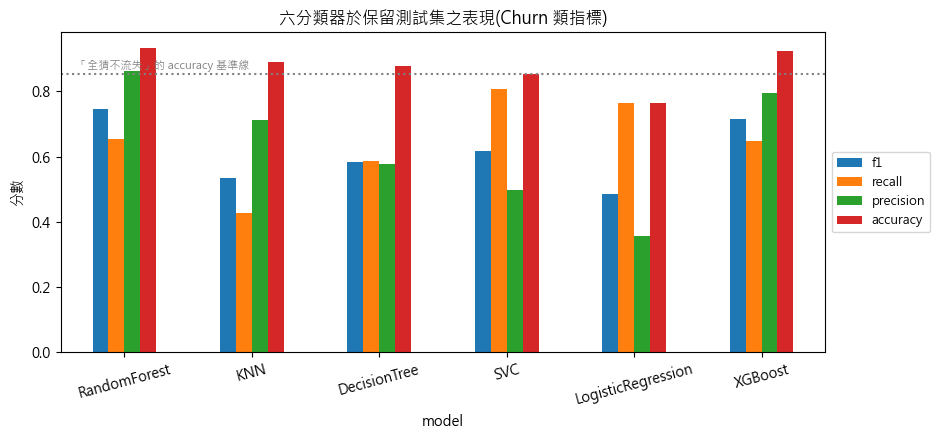

In [13]:
ax = test_df[["f1", "recall", "precision", "accuracy"]].plot.bar(
    figsize=(9.5, 4.5), rot=15
)
ax.set_title("六分類器於保留測試集之表現(Churn 類指標)")
ax.set_ylabel("分數")
ax.axhline(1 - df["Churn"].mean(), ls=":", c="grey")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
ax.text(
    0.02,
    1 - df["Churn"].mean() + 0.015,
    "「全猜不流失」的 accuracy 基準線",
    fontsize=8,
    color="grey",
    transform=ax.get_yaxis_transform(),
)
plt.tight_layout()
plt.savefig("figures/fig1_model_comparison.png", dpi=130)
plt.show()

#### 測試集上 RF 與 XGBoost 的差異是否有意義?(成對 bootstrap)

單次測試集上 RandomForest 的 F1(0.745)高於 XGBoost(0.715)。為避免以單一樣本下結論, 以**成對 bootstrap**(對同一批測試樣本重抽 2000 次)估計 F1 差的 95% 信賴區間; 若區間跨 0, 則差異在抽樣變異範圍內。

本筆記本依既定協議: **模型由訓練集 CV 選出, 測試集僅報告、不回選**。


In [14]:
rng = np.random.default_rng(RS)
yp_rf = fitted["RandomForest"].predict(X_test)
yp_xgb = fitted["XGBoost"].predict(X_test)
y_arr = y_test.values
diffs = []
n = len(y_arr)
for _ in range(2000):
    idx = rng.integers(0, n, n)
    diffs.append(f1_score(y_arr[idx], yp_rf[idx]) - f1_score(y_arr[idx], yp_xgb[idx]))
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(
    f"RF − XGBoost 測試集 F1 差:點估計 {test_df.loc['RandomForest','f1']-test_df.loc['XGBoost','f1']:+.4f},95% CI [{lo:+.4f}, {hi:+.4f}]"
)
print(
    "→ 信賴區間跨 0:單次測試集的 F1 差異無法排除抽樣變異,與 CV 的「統計不可分」結論一致。"
)
print(
    f"→ 最終模型維持由 CV 協議選出的 {winner};RandomForest 為表現相當的次選,將於報告中一併呈報。"
)

RF − XGBoost 測試集 F1 差:點估計 +0.0303,95% CI [-0.0009, +0.0635]
→ 信賴區間跨 0:單次測試集的 F1 差異無法排除抽樣變異,與 CV 的「統計不可分」結論一致。
→ 最終模型維持由 CV 協議選出的 XGBoost;RandomForest 為表現相當的次選,將於報告中一併呈報。


---

### 十、最終模型混淆矩陣與 FN 稽核

Churn=1 為正類; `labels=[0,1]` 固定矩陣順序。

False Negative(FN)= 實際流失(1)但被預測為不流失(0)= 公司未啟動挽留、客戶默默流失。


XGBoost(test): tn=831  fp=24  fn=51  tp=94


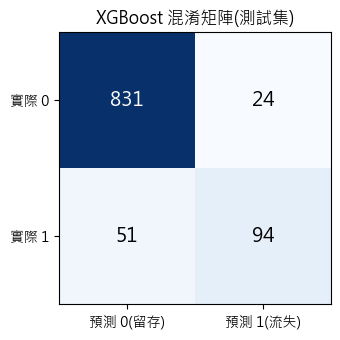


FN 稽核樣本(3 筆,確認實際 Churn=1 且被預測為 0):
      Churn  MonthlyCharge  predicted
1653      1           42.0          0
1842      1           69.0          0
2629      1           97.1          0


In [15]:
y_pred = fitted[winner].predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
print(f"{winner}(test): tn={tn}  fp={fp}  fn={fn}  tp={tp}")

fig, axm = plt.subplots(figsize=(4, 3.5))
cm = np.array([[tn, fp], [fn, tp]])
axm.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    axm.text(
        j,
        i,
        str(v),
        ha="center",
        va="center",
        color="white" if v > cm.max() / 2 else "black",
        fontsize=14,
    )
axm.set_xticks([0, 1], ["預測 0(留存)", "預測 1(流失)"])
axm.set_yticks([0, 1], ["實際 0", "實際 1"])
axm.set_title(f"{winner} 混淆矩陣(測試集)")
plt.tight_layout()
plt.savefig("figures/fig2_confusion_winner.png", dpi=130)
plt.show()

fn_mask = (y_test.values == 1) & (y_pred == 0)
fn_idx = X_test.index[fn_mask]
audit = df.loc[fn_idx[:3], ["Churn", "MonthlyCharge"]].assign(predicted=0)
print("\nFN 稽核樣本(3 筆,確認實際 Churn=1 且被預測為 0):")
print(audit.to_string())

---

### 十一、FN 的商業損失估算

三層呈現, 假設全部標明:

1. **毛收入暴露上限** = 測試集 FN 個體實際月費合計 × 留存月數假設(6 / 12 / 24 月敏感度)——上限,非實際損失

2. **預期可挽回價值** = 上限 × 挽留成功率假設 30%(產業經驗值,報告中附文獻)

3. **全資料集預估 FN 暴露** = 以測試集 FN 率外推:483 名流失者 × (51/145) ≈ **170 名預估漏抓**,再乘平均月費與留存假設——屬**推估**,單獨標示


In [16]:
fn_monthly = X_test.loc[fn_idx, "MonthlyCharge"]
SAVE_RATE = 0.30
churn_te = int((y_test == 1).sum())
est_fn_all = 483 * fn / churn_te
print(
    f"測試集 FN = {fn} 人(測試集共 {churn_te} 名流失者);FN 實際月費合計 = A${fn_monthly.sum():,.1f}(平均 A${fn_monthly.mean():.2f}/人/月)"
)
print(f"全資料集預估漏抓 ≈ 483 × {fn}/{churn_te} ≈ {est_fn_all:.0f} 名\n")
rows = []
for months in (6, 12, 24):
    gross = fn_monthly.sum() * months
    rows.append(
        {
            "留存假設(月)": months,
            "測試集FN毛暴露上限 (A$)": round(gross),
            f"預期可挽回 @{int(SAVE_RATE*100)}% (A$)": round(gross * SAVE_RATE),
            "全資料集預估FN暴露 (A$)": round(fn_monthly.mean() * est_fn_all * months),
        }
    )
loss_df = pd.DataFrame(rows).set_index("留存假設(月)")
print(loss_df.to_string())
print(
    f"\n基準情境(12 個月):測試集漏抓的 {fn} 名客戶 ≈ A${fn_monthly.sum()*12:,.0f} 年收入暴露上限;"
    f"若主動挽留能救回三成,約 A${fn_monthly.sum()*12*SAVE_RATE:,.0f} 為可挽回價值。"
)

測試集 FN = 51 人(測試集共 145 名流失者);FN 實際月費合計 = A$2,993.8(平均 A$58.70/人/月)
全資料集預估漏抓 ≈ 483 × 51/145 ≈ 170 名

         測試集FN毛暴露上限 (A$)  預期可挽回 @30% (A$)  全資料集預估FN暴露 (A$)
留存假設(月)                                                   
6                  17963             5389            59835
12                 35926            10778           119669
24                 71851            21555           239339

基準情境(12 個月):測試集漏抓的 51 名客戶 ≈ A$35,926 年收入暴露上限;若主動挽留能救回三成,約 A$10,778 為可挽回價值。


---

### 十二、變數重要性 — 各模型原生輸出

改進: 將範本的 Feature 0–9 索引對映回欄位名稱。

注意各模型的原生重要度**排序並不一致**(不純度、增益、係數等定義不同)——單看任何一個模型的原生重要度都不足以下結論, 見下節裁決。


In [17]:
native = pd.DataFrame(index=df_feature.columns)
for name in ("RandomForest", "DecisionTree", "XGBoost"):
    native[name] = fitted[name].named_steps["model"].feature_importances_
native["LogReg|coef|"] = np.abs(
    fitted["LogisticRegression"].named_steps["model"].coef_[0]
)
print("各模型原生重要度前三名:")
for col in native.columns:
    print(
        f"  {col:14s} → {', '.join(native[col].sort_values(ascending=False).head(3).index)}"
    )
native.round(4)

各模型原生重要度前三名:
  RandomForest   → DayMins, MonthlyCharge, CustServCalls
  DecisionTree   → DayMins, MonthlyCharge, CustServCalls
  XGBoost        → DataPlan, ContractRenewal, CustServCalls
  LogReg|coef|   → CustServCalls, ContractRenewal, DataPlan


,RandomForest,DecisionTree,XGBoost,LogReg|coef|
AccountWeeks,0.0635,0.0508,0.0079,0.0725
ContractRenewal,0.0730,0.0744,0.0714,0.6859
DataPlan,0.0332,0.0479,0.7656,0.5376
DataUsage,0.0771,0.0548,0.0161,0.0543
CustServCalls,0.1445,0.1242,0.0492,0.7722
DayMins,0.2070,0.2284,0.0314,0.4661
DayCalls,0.0638,0.0638,0.0086,0.0458
MonthlyCharge,0.1537,0.1404,0.0247,0.2806
OverageFee,0.0983,0.1035,0.0131,0.2522
RoamMins,0.0858,0.1119,0.0120,0.1653


---

### 十三、Permutation importance 裁決(最終模型, 測試集)+ 穩定性檢視

以 permutation importance(打亂某欄後 F1 的下降幅度)在測試集上重複 30 次。

**須注意: 此為「最終模型(XGBoost)的」重要度**, 衡量的是該模型的預測依賴, 非模型無關的普適結論; 因此除均值±標準差外, 另檢視 30 次重複中的**排序穩定性**(top-4 入選率、成對勝率), 避免過度宣稱。

重要度反映**預測關聯**, 不代表因果。


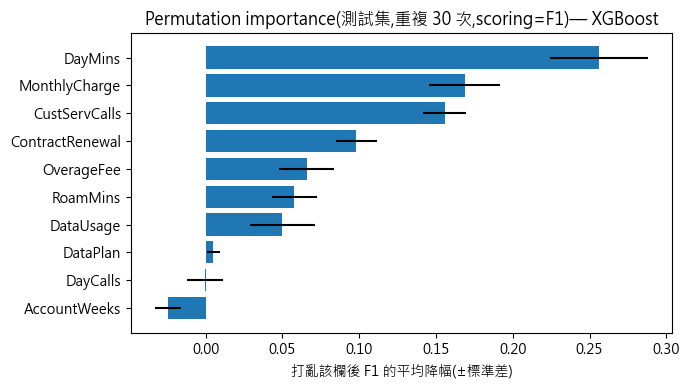

,feature,importance_mean,importance_std
0,DayMins,0.2560,0.0319
1,MonthlyCharge,0.1688,0.0230
2,CustServCalls,0.1557,0.0140
3,ContractRenewal,0.0981,0.0133
4,OverageFee,0.0659,0.0179
5,RoamMins,0.0579,0.0148
6,DataUsage,0.0499,0.0212
7,DataPlan,0.0049,0.0042
8,DayCalls,-0.0001,0.0118
9,AccountWeeks,-0.0244,0.0083


In [18]:
pi = permutation_importance(
    fitted[winner], X_test, y_test, n_repeats=30, random_state=RS, scoring="f1"
)
pi_df = (
    pd.DataFrame(
        {
            "feature": df_feature.columns,
            "importance_mean": pi.importances_mean,
            "importance_std": pi.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
fig, axp = plt.subplots(figsize=(7, 4))
axp.barh(
    pi_df.feature[::-1], pi_df.importance_mean[::-1], xerr=pi_df.importance_std[::-1]
)
axp.set_xlabel("打亂該欄後 F1 的平均降幅(±標準差)")
axp.set_title(f"Permutation importance(測試集,重複 30 次,scoring=F1)— {winner}")
plt.tight_layout()
plt.savefig("figures/fig3_perm_importance.png", dpi=130)
plt.show()
pi_df.round(4)

In [19]:
# 排序穩定性:30 次重複中,各變數進入該次 top-4 的比率;以及第 2、3 名的成對勝率
imp = pi.importances  # shape (n_features, n_repeats)
feat = list(df_feature.columns)
ranks = np.argsort(-imp, axis=0)  # 每次重複的名次序
top4_count = {f: 0 for f in feat}
for r in range(imp.shape[1]):
    for f_idx in ranks[:4, r]:
        top4_count[feat[f_idx]] += 1
top4_rate = pd.Series(top4_count).sort_values(ascending=False) / imp.shape[1]
print("各變數 30 次重複中進入 top-4 的比率:")
print(
    (top4_rate[top4_rate > 0] * 100)
    .round(0)
    .astype(int)
    .astype(str)
    .add("%")
    .to_string()
)

i_mc, i_cs = feat.index("MonthlyCharge"), feat.index("CustServCalls")
win_mc = int((imp[i_mc] > imp[i_cs]).sum())
print(f"\n成對勝率:MonthlyCharge > CustServCalls 於 {win_mc}/30 次重複")
print(
    """
穩定性結論:DayMins 於 30/30 次穩居第一;MonthlyCharge 與 CustServCalls 互有領先(上表成對勝率),
應視為**同一層級**的第二梯隊;ContractRenewal 多數重複位居第四。
→ 裁決:最重要變數 = DayMins;第二層級 = MonthlyCharge 與 CustServCalls(不強分先後);第四 = ContractRenewal。"""
)

各變數 30 次重複中進入 top-4 的比率:
CustServCalls      100%
DayMins            100%
MonthlyCharge      100%
ContractRenewal     90%
DataUsage            7%
OverageFee           3%

成對勝率:MonthlyCharge > CustServCalls 於 23/30 次重複

穩定性結論:DayMins 於 30/30 次穩居第一;MonthlyCharge 與 CustServCalls 互有領先(上表成對勝率),
應視為**同一層級**的第二梯隊;ContractRenewal 多數重複位居第四。
→ 裁決:最重要變數 = DayMins;第二層級 = MonthlyCharge 與 CustServCalls(不強分先後);第四 = ContractRenewal。


---

### 十四、三層論證第二層: 重要變數在流失/未流失群組間的實際差異

Permutation importance 只說明「模型依賴哪些變數」。

此處以**原始資料的群組差異**驗證這些變數確實在流失者與未流失者間有實質差別(第三層——領域知識與外部文獻——見報告)。


In [20]:
key_vars = ["DayMins", "MonthlyCharge", "CustServCalls", "ContractRenewal"]
grp = df.groupby("Churn")[key_vars].mean().T
grp.columns = ["未流失 (Churn=0)", "流失 (Churn=1)"]
grp["差異方向"] = np.where(
    grp["流失 (Churn=1)"] > grp["未流失 (Churn=0)"], "流失者較高", "流失者較低"
)
print(grp.round(3).to_string())
print(
    f"""
解讀(預測關聯,非因果):
- DayMins:流失者平均日間通話 {grp.loc['DayMins','流失 (Churn=1)']:.0f} 分 vs 未流失 {grp.loc['DayMins','未流失 (Churn=0)']:.0f} 分 → 高用量客戶帳單壓力大、對價格與體驗更敏感
- MonthlyCharge:流失者月費較高({grp.loc['MonthlyCharge','流失 (Churn=1)']:.1f} vs {grp.loc['MonthlyCharge','未流失 (Churn=0)']:.1f})→ 與 DayMins 相關,反映「高帳單」族群
- CustServCalls:流失者客服來電 {grp.loc['CustServCalls','流失 (Churn=1)']:.2f} 次 vs {grp.loc['CustServCalls','未流失 (Churn=0)']:.2f} 次 → 來電頻率是不滿的行為信號
- ContractRenewal:流失者續約率僅 {grp.loc['ContractRenewal','流失 (Churn=1)']*100:.1f}% vs 未流失 {grp.loc['ContractRenewal','未流失 (Churn=0)']*100:.1f}% → 未續約 = 轉換成本低"""
)

                 未流失 (Churn=0)  流失 (Churn=1)   差異方向
DayMins                175.176       206.914  流失者較高
MonthlyCharge           55.816        59.190  流失者較高
CustServCalls            1.450         2.230  流失者較高
ContractRenewal          0.935         0.716  流失者較低

解讀(預測關聯,非因果):
- DayMins:流失者平均日間通話 207 分 vs 未流失 175 分 → 高用量客戶帳單壓力大、對價格與體驗更敏感
- MonthlyCharge:流失者月費較高(59.2 vs 55.8)→ 與 DayMins 相關,反映「高帳單」族群
- CustServCalls:流失者客服來電 2.23 次 vs 1.45 次 → 來電頻率是不滿的行為信號
- ContractRenewal:流失者續約率僅 71.6% vs 未流失 93.5% → 未續約 = 轉換成本低


#### 補充: 重要變數間的相關性與策略試點門檻(供報告第三、四節)

DayMins 與 MonthlyCharge 的相關係數, 以及報告第四節三個試點門檻的實際客群規模與流失率。


In [21]:
r_dm = df["DayMins"].corr(df["MonthlyCharge"])
print(
    f"DayMins 與 MonthlyCharge 相關係數 r = {r_dm:.2f}(中度相關 → 重要度可能互相分攤)\n"
)
base = df["Churn"].mean()
segs = {
    "行動一:CustServCalls >= 3": df["CustServCalls"] >= 3,
    "行動二:ContractRenewal == 0(未續約)": df["ContractRenewal"] == 0,
    "行動三:DayMins >= 216 且 MonthlyCharge >= 中位(53.5)": (df["DayMins"] >= 216)
    & (df["MonthlyCharge"] >= df["MonthlyCharge"].median()),
}
print(f"全體:{len(df)} 人,流失率 {base*100:.1f}%")
for name, mask in segs.items():
    g = df[mask]
    print(
        f"{name}:{len(g)} 人({len(g)/len(df)*100:.0f}%),流失率 {g['Churn'].mean()*100:.1f}%,為全體的 {g['Churn'].mean()/base:.1f} 倍"
    )

DayMins 與 MonthlyCharge 相關係數 r = 0.57(中度相關 → 重要度可能互相分攤)

全體:3333 人,流失率 14.5%
行動一:CustServCalls >= 3:696 人(21%),流失率 26.1%,為全體的 1.8 倍
行動二:ContractRenewal == 0(未續約):323 人(10%),流失率 42.4%,為全體的 2.9 倍
行動三:DayMins >= 216 且 MonthlyCharge >= 中位(53.5):767 人(23%),流失率 31.3%,為全體的 2.2 倍


#### 補充二: 三項行動的量化商業案例(供報告表五)

沿用上一格的三個試點門檻, 加入成本假設, 計算**損益兩平所需的增量留存率**與**預期淨效益**。

- 人數與流失率: 本資料集實算(上一格)

- 成本與毛利率: **估計假設**, 已於輸出中明列

- 誘因成本僅於**挽留成功**時發生; 接觸成本對全體試點對象發生


In [22]:
# ── 假設(明列,非由資料推得)──
GROSS_MARGIN, HORIZON_M, UPLIFT = 0.60, 12, 0.20
avg_fee = fn_monthly.mean()  # 沿用第十一節 FN 群平均月費
MARGIN_PER_SAVE = round(avg_fee * HORIZON_M * GROSS_MARGIN)

print(
    f"假設:毛利率 {GROSS_MARGIN:.0%}、成功挽回客戶以 {HORIZON_M} 個月計、平均月費 A${avg_fee:.2f}"
)
print(
    f"  → 每名成功挽回客戶毛利 ≈ A${avg_fee:.2f} × {HORIZON_M} × {GROSS_MARGIN:.0%} ≈ A${MARGIN_PER_SAVE}"
)
print(f"情境:試點相對隨機對照組的增量留存率 = {UPLIFT:.0%}\n")

# 每人接觸成本、成功挽留誘因成本(對應上一格 segs 的三個門檻,順序相同)
COSTS = [
    (15, 0),  # 一、服務恢復:專員回訪工時,無誘因
    (5, round(avg_fee)),  # 二、續約轉化:一個月費折抵
    (10, round(avg_fee * 0.10 * HORIZON_M)),
]  # 三、資費重組:月費調降 10% 一年

rows = []
for (seg_name, mask), (contact, incent) in zip(segs.items(), COSTS):
    g = df[mask]
    n = len(g)
    exp_churn = n * g["Churn"].mean()  # 該群預期流失人數
    invest = n * contact  # 試點總投入
    net_per = MARGIN_PER_SAVE - incent  # 每挽回一人的淨毛利
    be_rate = invest / net_per / exp_churn  # 損益兩平所需增量留存率
    net = exp_churn * UPLIFT * net_per - invest  # 該情境下的淨效益
    rows.append(
        {
            "行動": seg_name.split(":")[0],
            "每人接觸成本": f"A${contact}",
            "成功挽留誘因": f"A${incent}" if incent else "—",
            "試點總投入": f"A${invest:,.0f}",
            "該群預期流失": f"{exp_churn:.0f} 人",
            "損益兩平增量留存率": f"{be_rate*100:.1f}%",
            f"淨效益 @{UPLIFT:.0%}": f"+A${net:,.0f}",
        }
    )

t5 = pd.DataFrame(rows)
print(t5.to_string(index=False))
print("\n註:損益兩平 = 試點總投入 ÷ 每名挽回客戶淨毛利 ÷ 該群預期流失人數。")
print("三組門檻各自獨立、可能重疊;上表為各行動單獨實施的情境,不得加總。")

假設:毛利率 60%、成功挽回客戶以 12 個月計、平均月費 A$58.70
  → 每名成功挽回客戶毛利 ≈ A$58.70 × 12 × 60% ≈ A$423
情境:試點相對隨機對照組的增量留存率 = 20%

 行動 每人接觸成本 成功挽留誘因    試點總投入 該群預期流失 損益兩平增量留存率 淨效益 @20%
行動一   A$15      — A$10,440  182 人     13.6% +A$4,957
行動二    A$5   A$59  A$1,615  137 人      3.2% +A$8,359
行動三   A$10   A$70  A$7,670  240 人      9.1% +A$9,274

註:損益兩平 = 試點總投入 ÷ 每名挽回客戶淨毛利 ÷ 該群預期流失人數。
三組門檻各自獨立、可能重疊;上表為各行動單獨實施的情境,不得加總。


---

### 附錄 A: 決策閾值的成本敏感度(情境展示, 非正式答案)

> **本作業的正式答案始終為第十節: 最終模型以原生 predict 得出 FN = 51。**
>
> 本附錄僅展示: 若管理層願意以「多發挽留 offer」換「少漏抓流失者」, 決策閾值如何隨成本假設移動(FN ≈ 12 個月月費、FP ≈ 1 個月挽留 offer, 比約 12:1; 成本比取決於實際 offer 設計, 故此為情境而非推薦)。


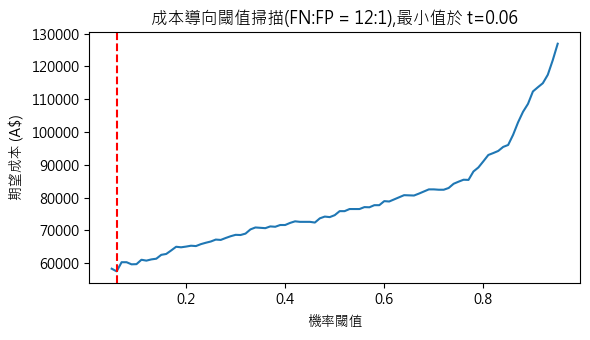

情境比較(測試集):正式答案(原生 predict)FN=51, FP=24;成本最小閾值 t=0.06 情境 FN=34, FP=114
→ 該情境下多發 90 份挽留 offer 可少漏抓 17 名流失客戶;是否值得取決於挽留成本的實際設計。


In [23]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
proba_cv = cross_val_predict(
    build(winner, chosen[winner]), X_train, y_train, cv=cv5, method="predict_proba"
)[:, 1]
med_fee = float(df["MonthlyCharge"].median())
ths = np.arange(0.05, 0.951, 0.01)
costs = []
for t in ths:
    yp_t = (proba_cv >= t).astype(int)
    _tn, _fp, _fn, _tp = confusion_matrix(y_train, yp_t, labels=[0, 1]).ravel()
    costs.append(_fn * 12 * med_fee + _fp * 1 * med_fee)
best_t = float(ths[int(np.argmin(costs))])
fig, axc = plt.subplots(figsize=(6, 3.5))
axc.plot(ths, costs)
axc.axvline(best_t, ls="--", c="r")
axc.set_xlabel("機率閾值")
axc.set_ylabel("期望成本 (A$)")
axc.set_title(f"成本導向閾值掃描(FN:FP = 12:1),最小值於 t={best_t:.2f}")
plt.tight_layout()
plt.savefig("figures/fig4_threshold_cost.png", dpi=130)
plt.show()

proba_te = fitted[winner].predict_proba(X_test)[:, 1]
yp_bt = (proba_te >= best_t).astype(int)
btn, bfp, bfn, btp = confusion_matrix(y_test, yp_bt, labels=[0, 1]).ravel()
print(
    f"情境比較(測試集):正式答案(原生 predict)FN={fn}, FP={fp};成本最小閾值 t={best_t:.2f} 情境 FN={bfn}, FP={bfp}"
)
print(
    f"→ 該情境下多發 {bfp-fp} 份挽留 offer 可少漏抓 {fn-bfn} 名流失客戶;是否值得取決於挽留成本的實際設計。"
)

---

### 附錄 B: AdaBoost(範本 import 的第七個分類器)

題目指定六模型比較; AdaBoost 為範本附帶, 在此補充展示(不參與六模型推薦)。


In [24]:
ada = Pipeline([("model", AdaBoostClassifier(random_state=RS, algorithm="SAMME"))]).fit(
    X_train, y_train
)
yp_a = ada.predict(X_test)
atn, afp, afn, atp = confusion_matrix(y_test, yp_a, labels=[0, 1]).ravel()
print(
    f"AdaBoost(SAMME, test): accuracy={accuracy_score(y_test,yp_a):.4f}  precision={precision_score(y_test,yp_a):.4f}  "
    f"recall={recall_score(y_test,yp_a):.4f}  F1={f1_score(y_test,yp_a):.4f}  (tn={atn} fp={afp} fn={afn} tp={atp})"
)

AdaBoost(SAMME, test): accuracy=0.8840  precision=0.6790  recall=0.3793  F1=0.4867  (tn=829 fp=26 fn=90 tp=55)


---

### 十五、本筆記本產出摘要(供報告引用)


In [25]:
print(
    f"最終模型:{winner}(預設配置)。選模依據:5-fold × 5 repeats(共 25 個折次)重複 CV 中六模型以 churn-F1 排序,"
)
print(
    f"前二名(XGBoost/RandomForest)經 Nadeau–Bengio 校正檢定統計不可分,依預先訂定的平手鏈以 recall 均值裁決。"
)
print(
    f"測試集(正式答案):accuracy={test_df.loc[winner,'accuracy']:.3f}  precision={test_df.loc[winner,'precision']:.3f}  "
    f"recall={test_df.loc[winner,'recall']:.3f}  F1={test_df.loc[winner,'f1']:.3f};RandomForest 為表現相當的次選。"
)
print(
    f"FN = {fn} 人(測試集);月費合計 A${fn_monthly.sum():,.1f};12 個月毛暴露上限 ≈ A${fn_monthly.sum()*12:,.0f};"
)
print(
    f"@30% 挽留率可挽回 ≈ A${fn_monthly.sum()*12*0.3:,.0f};全資料集預估漏抓 ≈ {est_fn_all:.0f} 名。"
)
print(
    f"最重要變數:DayMins(30/30 穩居第一);第二層級 MonthlyCharge 與 CustServCalls;第四 ContractRenewal。"
)
print(
    f"群組差異佐證:流失者日間通話 207 vs 175 分、客服來電 2.23 vs 1.45 次、續約率 71.6% vs 93.5%。"
)

最終模型:XGBoost(預設配置)。選模依據:5-fold × 5 repeats(共 25 個折次)重複 CV 中六模型以 churn-F1 排序,
前二名(XGBoost/RandomForest)經 Nadeau–Bengio 校正檢定統計不可分,依預先訂定的平手鏈以 recall 均值裁決。
測試集(正式答案):accuracy=0.925  precision=0.797  recall=0.648  F1=0.715;RandomForest 為表現相當的次選。
FN = 51 人(測試集);月費合計 A$2,993.8;12 個月毛暴露上限 ≈ A$35,926;
@30% 挽留率可挽回 ≈ A$10,778;全資料集預估漏抓 ≈ 170 名。
最重要變數:DayMins(30/30 穩居第一);第二層級 MonthlyCharge 與 CustServCalls;第四 ContractRenewal。
群組差異佐證:流失者日間通話 207 vs 175 分、客服來電 2.23 vs 1.45 次、續約率 71.6% vs 93.5%。
